# MedCore Catalogue — Text Extraction OCR Benchmark
**Track A: Text Extraction** — benchmarking **EasyOCR** vs **Tesseract OCR** against the programmatically-verified text ground truth generated for the MedCore synthetic catalogue.

**Inputs expected (added as Kaggle Dataset / Notebook Input):**
- `MedCore_Catalogue_v2.pdf` — the source document (a zip-based container of per-page JPEGs + text, bundled with a `.pdf` extension)
- `MedCore_GT_v2.json` — original layout-only ground truth (bbox + class)
- `MedCore_GT_v2_with_text.json` — layout GT augmented with verified `gt_text` per zone (**primary GT source for this notebook**)
- `MedCore_text_gt_flat.csv` — flat CSV view of the same text GT (used as a fallback source)

**Metrics:** Character Error Rate (CER) and Word Error Rate (WER) via `jiwer`, computed both corpus-level (micro-averaged) and per-zone, plus an exact-match rate — per the Track A metrics decided in the benchmarking research report.

> ⚠️ **Before running:** in Kaggle notebook Settings, turn **Internet → On** (needed to `pip install easyocr jiwer` and `apt-get install tesseract-ocr` if not already present in the image). A GPU accelerator is optional but speeds up EasyOCR.


## 1. Setup

In [1]:
# Install packages not guaranteed to be preinstalled on Kaggle.
# Safe to re-run; failures here (e.g. tesseract already present) are non-fatal.
!pip install --quiet jiwer easyocr pytesseract
!apt-get update -qq && apt-get install -y -qq tesseract-ocr || true



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


'apt-get' is not recognized as an internal or external command,
operable program or batch file.
'true' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os, glob, json, re, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 80)


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Locate Input Files

In [3]:
# Kaggle mounts uploaded datasets under /kaggle/input/<dataset-slug>/...
# Auto-discover the 4 expected files by name pattern so this notebook doesn't
# depend on the exact dataset slug you choose when uploading.

SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working", "."]

def find_file(patterns, search_roots=SEARCH_ROOTS):
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for pattern in patterns:
            matches = sorted(glob.glob(os.path.join(root, "**", pattern), recursive=True))
            if matches:
                return matches[0]
    return None

# If auto-discovery fails for any file, hardcode its path here manually.
MANUAL_PATHS = {
    "pdf": None,
    "gt_with_text": None,
    "gt_layout_only": None,
    "gt_flat_csv": None,
}

PATHS = {
    "pdf":            MANUAL_PATHS["pdf"]            or find_file(["*MedCore_Catalogue*.pdf", "*.pdf"]),
    "gt_with_text":   MANUAL_PATHS["gt_with_text"]   or find_file(["*MedCore_GT_v2_with_text*.json", "*with_text*.json"]),
    "gt_layout_only": MANUAL_PATHS["gt_layout_only"] or find_file(["MedCore_GT_v2.json"]),
    "gt_flat_csv":    MANUAL_PATHS["gt_flat_csv"]    or find_file(["*MedCore_text_gt_flat*.csv", "*text_gt_flat*.csv"]),
}

print("Resolved input paths:")
for k, v in PATHS.items():
    print(f"  {k:16s} -> {v}")

assert PATHS["pdf"] is not None, "Could not find the catalogue PDF — set MANUAL_PATHS[\'pdf\']"
assert (PATHS["gt_with_text"] or PATHS["gt_flat_csv"]) is not None, \
    "Could not find MedCore_GT_v2_with_text.json or MedCore_text_gt_flat.csv — set a MANUAL_PATHS entry"


Resolved input paths:
  pdf              -> .\MedCore_Catalogue_v2.pdf
  gt_with_text     -> .\MedCore_GT_v2_with_text.json
  gt_layout_only   -> .\MedCore_GT_v2.json
  gt_flat_csv      -> .\MedCore_text_gt_flat.csv


## 3. Load Page Images from the Catalogue

In [4]:
import zipfile

def load_page_images(path):
    """
    Returns {page_number: PIL.Image} for the MedCore catalogue.
    The provided "PDF" is actually a zip container of per-page JPEGs + text +
    a manifest.json (confirmed during GT generation). Falls back to rendering
    a genuine PDF via PyMuPDF if the file isn\'t a zip.
    """
    images = {}
    if zipfile.is_zipfile(path):
        with zipfile.ZipFile(path) as z:
            names = z.namelist()
            manifest_name = next((n for n in names if n.endswith("manifest.json")), None)
            if manifest_name:
                manifest = json.loads(z.read(manifest_name))
                for p in manifest["pages"]:
                    img_bytes = z.read(p["image"]["path"])
                    images[p["page_number"]] = Image.open(io.BytesIO(img_bytes)).convert("RGB")
            else:
                for n in names:
                    if n.lower().endswith((".jpg", ".jpeg", ".png")):
                        stem = os.path.splitext(os.path.basename(n))[0]
                        if stem.isdigit():
                            images[int(stem)] = Image.open(io.BytesIO(z.read(n))).convert("RGB")
    else:
        try:
            import fitz  # PyMuPDF
        except ImportError:
            os.system("pip install --quiet pymupdf")
            import fitz
        doc = fitz.open(path)
        for i, page in enumerate(doc, start=1):
            pix = page.get_pixmap(matrix=fitz.Matrix(2, 2))
            images[i] = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
    return images

page_images = load_page_images(PATHS["pdf"])
print(f"Loaded {len(page_images)} page images:")
for p, im in sorted(page_images.items()):
    print(f"  page {p}: {im.size}")


Loaded 4 page images:
  page 1: (1191, 1684)
  page 2: (1191, 1684)
  page 3: (1191, 1684)
  page 4: (1191, 1684)


## 4. Load Text Ground Truth

In [5]:
def load_zones():
    """Builds a DataFrame of text-bearing layout zones with verified gt_text.
    Prefers the richer *_with_text.json; falls back to the flat CSV."""
    if PATHS["gt_with_text"]:
        with open(PATHS["gt_with_text"], encoding="utf-8") as f:
            gt_full = json.load(f)
        rows = []
        for page in gt_full["pages"]:
            for el in page["elements"]:
                if el.get("gt_text_status") == "programmatic_verified" and el.get("gt_text"):
                    rows.append({
                        "id": el["id"], "page": el["page"], "class": el["class"],
                        "gt_text": el["gt_text"], "bbox_norm": el["bbox_norm"],
                    })
        return pd.DataFrame(rows)
    else:
        df = pd.read_csv(PATHS["gt_flat_csv"])
        df = df[df["gt_text_status"] == "programmatic_verified"].copy()
        df["bbox_norm"] = df["bbox_norm"].apply(json.loads)
        return df[["id", "page", "class", "gt_text", "bbox_norm"]].reset_index(drop=True)

zones_df = load_zones()
n_pages = zones_df["page"].nunique()
print(f"Loaded {len(zones_df)} text-bearing GT zones across {n_pages} pages")
zones_df.groupby("class").size().sort_values(ascending=False)


Loaded 64 text-bearing GT zones across 4 pages


class
paragraph         14
title             14
section_header     8
caption            6
price_tag          6
spec_list          6
footer             4
header             4
list               2
dtype: int64

## 5. Crop Each Zone From Its Page Image

Generated 64 crops.


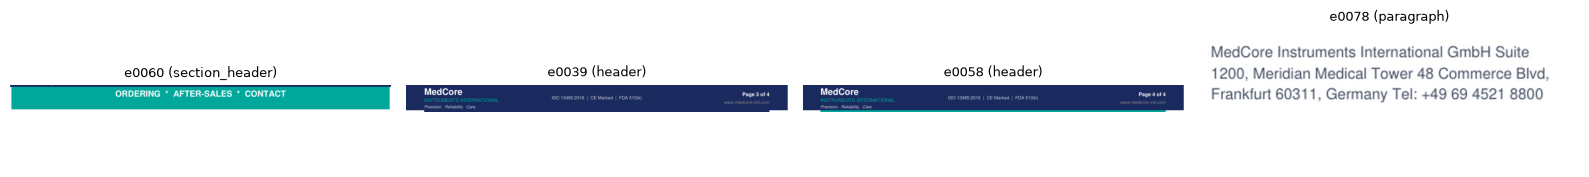

In [6]:
PAD_PX = 4
UPSCALE_FACTOR = 3  # native page images are ~924x1316px, so individual zones
                     # (e.g. a price tag) can be tiny — upscale before OCR.

def crop_zone(page_images, row, pad=PAD_PX, upscale=UPSCALE_FACTOR):
    img = page_images[row["page"]]
    W, H = img.size
    bn = row["bbox_norm"]
    x0 = max(0, bn["x"] * W - pad)
    y0 = max(0, bn["y"] * H - pad)
    x1 = min(W, (bn["x"] + bn["w"]) * W + pad)
    y1 = min(H, (bn["y"] + bn["h"]) * H + pad)
    crop = img.crop((x0, y0, x1, y1))
    if upscale and upscale != 1:
        crop = crop.resize((crop.width * upscale, crop.height * upscale), Image.LANCZOS)
    return crop

crops = {row["id"]: crop_zone(page_images, row) for _, row in zones_df.iterrows()}
print(f"Generated {len(crops)} crops.")

# quick visual sanity check
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, (_, row) in zip(axes, zones_df.sample(4, random_state=0).iterrows()):
    ax.imshow(crops[row["id"]])
    ax.set_title(f"{row['id']} ({row['class']})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Baseline Model 1 — EasyOCR

In [7]:
import torch
import easyocr

USE_GPU = torch.cuda.is_available()
print("EasyOCR GPU:", USE_GPU)
reader = easyocr.Reader(["en"], gpu=USE_GPU, verbose=False)

def reconstruct_reading_order(detections, line_threshold_ratio=0.6):
    """EasyOCR returns detections in detection/confidence order, not reading
    order. Cluster boxes into lines by vertical overlap, then sort
    left-to-right within each line, top-to-bottom across lines."""
    if not detections:
        return ""
    items = []
    for box, text, conf in detections:
        ys = [p[1] for p in box]; xs = [p[0] for p in box]
        items.append({"x0": min(xs), "y0": min(ys), "y1": max(ys),
                       "yc": (min(ys) + max(ys)) / 2, "text": text})
    items.sort(key=lambda d: (d["y0"], d["x0"]))
    avg_h = float(np.mean([d["y1"] - d["y0"] for d in items])) or 1.0
    lines, current = [], [items[0]]
    for d in items[1:]:
        ref_yc = np.mean([c["yc"] for c in current])
        if abs(d["yc"] - ref_yc) <= line_threshold_ratio * avg_h:
            current.append(d)
        else:
            lines.append(current); current = [d]
    lines.append(current)
    out = []
    for line in lines:
        line.sort(key=lambda d: d["x0"])
        out.append(" ".join(d["text"] for d in line))
    return "\n".join(out)

def run_easyocr(crop_img):
    detections = reader.readtext(np.array(crop_img))
    return reconstruct_reading_order(detections)

easyocr_preds = {}
for zone_id, crop in tqdm(crops.items(), desc="EasyOCR"):
    try:
        easyocr_preds[zone_id] = run_easyocr(crop)
    except Exception as e:
        print(f"EasyOCR failed on {zone_id}: {e}")
        easyocr_preds[zone_id] = ""


EasyOCR GPU: False


EasyOCR:   0%|          | 0/64 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


EasyOCR:   2%|▏         | 1/64 [00:02<02:33,  2.44s/it]

EasyOCR:   3%|▎         | 2/64 [00:05<03:10,  3.08s/it]

...

EasyOCR:  95%|█████████▌| 61/64 [01:25<00:02,  1.01it/s]

EasyOCR:  97%|█████████▋| 62/64 [01:26<00:02,  1.22s/it]

EasyOCR:  98%|█████████▊| 63/64 [01:28<00:01,  1.46s/it]

EasyOCR: 100%|██████████| 64/64 [01:30<00:00,  1.47s/it]

EasyOCR: 100%|██████████| 64/64 [01:30<00:00,  1.41s/it]

## 7. Baseline Model 2 — Tesseract OCR

In [8]:
import pytesseract
import os
if os.name == 'nt':
    tess_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
    if os.path.exists(tess_path):
        pytesseract.pytesseract.tesseract_cmd = tess_path


try:
    print("Tesseract version:", pytesseract.get_tesseract_version())
except Exception as e:
    raise RuntimeError(
        "Tesseract binary not found. Run: !apt-get install -y tesseract-ocr "
        "(and ensure Internet is ON in notebook settings)."
    ) from e

TESS_CONFIG = "--psm 6"  # "assume a single uniform block of text" — fits cropped layout zones

def run_tesseract(crop_img):
    return pytesseract.image_to_string(crop_img, config=TESS_CONFIG).strip()

tesseract_preds = {}
for zone_id, crop in tqdm(crops.items(), desc="Tesseract"):
    try:
        tesseract_preds[zone_id] = run_tesseract(crop)
    except Exception as e:
        print(f"Tesseract failed on {zone_id}: {e}")
        tesseract_preds[zone_id] = ""


Tesseract version: 5.4.0.20240606


Tesseract:   0%|          | 0/64 [00:00<?, ?it/s]

Tesseract:   2%|▏         | 1/64 [00:00<00:34,  1.80it/s]

Tesseract:   3%|▎         | 2/64 [00:01<00:31,  1.96it/s]

Tesseract:   5%|▍         | 3/64 [00:01<00:25,  2.35it/s]

...

Tesseract:  95%|█████████▌| 61/64 [00:17<00:00,  4.03it/s]

Tesseract:  97%|█████████▋| 62/64 [00:17<00:00,  3.73it/s]

Tesseract:  98%|█████████▊| 63/64 [00:18<00:00,  3.51it/s]

Tesseract: 100%|██████████| 64/64 [00:18<00:00,  3.71it/s]

Tesseract: 100%|██████████| 64/64 [00:18<00:00,  3.50it/s]

## 8. Evaluation Metrics — CER / WER / Exact Match

In [9]:
import jiwer

def normalize_text(s):
    """Whitespace/case normalization only — punctuation and digits are kept,
    since dropped punctuation/units (e.g. \':\' or \'/\') are real OCR errors we
    want CER/WER to capture."""
    if s is None:
        return ""
    s = s.replace("\n", " ")
    s = re.sub(r"\s+", " ", s)
    return s.strip().lower()

def safe_metric(fn, ref, hyp):
    try:
        return fn(ref, hyp)
    except Exception:
        return float("nan")

def score_zone(gt_text, pred_text):
    ref, hyp = normalize_text(gt_text), normalize_text(pred_text)
    cer = safe_metric(jiwer.cer, ref, hyp)
    wer = safe_metric(jiwer.wer, ref, hyp)
    exact_match = int(ref == hyp)
    return cer, wer, exact_match

records = []
for _, row in zones_df.iterrows():
    zid, cls, page, gt_text = row["id"], row["class"], row["page"], row["gt_text"]
    for model_name, preds in [("easyocr", easyocr_preds), ("tesseract", tesseract_preds)]:
        pred_text = preds.get(zid, "")
        cer, wer, em = score_zone(gt_text, pred_text)
        records.append({
            "id": zid, "page": page, "class": cls, "model": model_name,
            "gt_text": gt_text, "pred_text": pred_text,
            "CER": cer, "WER": wer, "exact_match": em,
        })

results_df = pd.DataFrame(records)
results_df.head(10)


,id,page,class,model,gt_text,pred_text,CER,WER,exact_match
0,e0001,1,header,easyocr,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 1 of...,MedCore Page 1 of 4\nINSTRUMENTS INTERNATIONAL ISO 13485.2016 1 CE Marked 3 ...,0.632353,0.789474,0
1,e0001,1,header,tesseract,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 1 of...,MedCore ISO 13485:2016 | CE Marked | FDA 510(k HOU GI\nINSTRUMENTS INTERNATI...,0.808824,0.947368,0
2,e0002,1,footer,easyocr,ISO 13485:2016 CE Marked FDA 510(k) ENERGY STAR\n+49 69 4521 8800 |...,ISO 13485.2016 CE Marked FDA 510(k) ENERGY STAR\n+49 69 4521 8800 procuremen...,0.061538,0.300000,0
3,e0002,1,footer,tesseract,ISO 13485:2016 CE Marked FDA 510(k) ENERGY STAR\n+49 69 4521 8800 |...,ISO 13485:2016 CE Marked FDA 510(k) ENERGY STAR\n+49 69 4521 8800 | procurem...,0.000000,0.000000,1
4,e0004,1,title,easyocr,2024 - 2025 PRODUCT CATALOGUE,2uz4 Zuzj Phudu6i GATALOGUE,0.448276,1.000000,0
5,e0004,1,title,tesseract,2024 - 2025 PRODUCT CATALOGUE,0 UES £ULZOI PRAUYVUUT CALTALUUUE UL,0.758621,1.200000,0
6,e0005,1,title,easyocr,Advanced Diagnostic & Surgical Instruments,Aavanced Dlagnostic & Surgical instruments,0.047619,0.400000,0
7,e0005,1,title,tesseract,Advanced Diagnostic & Surgical Instruments,Aavanced Viagnostic & ourgical instruments,0.071429,0.600000,0
8,e0006,1,paragraph,easyocr,For ICUs | Operation Theatres | Diagnostic Labs | General Practice,For ICUs | Operation Theatres Diagnostic Labs General Practice,0.060606,0.181818,0
9,e0006,1,paragraph,tesseract,For ICUs | Operation Theatres | Diagnostic Labs | General Practice,For ICUs | Operation Theatres | Diagnostic Labs | General Practice,0.000000,0.000000,1


## 9. Leaderboard — Corpus-Level & Per-Class

In [10]:
def corpus_level_scores(df, model_name):
    sub = df[df["model"] == model_name]
    refs = [normalize_text(t) for t in sub["gt_text"]]
    hyps = [normalize_text(t) for t in sub["pred_text"]]
    return {
        "model": model_name,
        "corpus_CER": jiwer.cer(refs, hyps),   # micro-avg: total edits / total chars
        "corpus_WER": jiwer.wer(refs, hyps),
        "macro_CER": sub["CER"].mean(),        # simple mean across zones
        "macro_WER": sub["WER"].mean(),
        "exact_match_rate": sub["exact_match"].mean(),
        "n_zones": len(sub),
    }

leaderboard = pd.DataFrame([corpus_level_scores(results_df, m) for m in ["easyocr", "tesseract"]])
leaderboard = leaderboard.set_index("model").sort_values("corpus_CER")
print("=== Overall Leaderboard (lower CER/WER is better) ===")
leaderboard


=== Overall Leaderboard (lower CER/WER is better) ===


,corpus_CER,corpus_WER,macro_CER,macro_WER,exact_match_rate,n_zones
model,,,,,,
easyocr,0.107820,0.230769,0.080582,0.197255,0.3125,64
tesseract,0.132751,0.183217,0.111067,0.171347,0.6875,64


In [11]:
per_class = (results_df.groupby(["class", "model"])[["CER", "WER", "exact_match"]]
             .mean()
             .reset_index()
             .sort_values(["class", "model"]))
per_class


,class,model,CER,WER,exact_match
0,caption,easyocr,0.022540,0.088889,0.666667
1,caption,tesseract,0.372516,0.488889,0.333333
2,footer,easyocr,0.077885,0.276923,0.000000
3,footer,tesseract,0.120833,0.163462,0.250000
4,header,easyocr,0.625000,0.789474,0.000000
5,header,tesseract,0.790441,0.986842,0.000000
6,list,easyocr,0.025157,0.095238,0.500000
7,list,tesseract,0.012579,0.095238,0.500000
8,paragraph,easyocr,0.020581,0.128597,0.214286
9,paragraph,tesseract,0.000000,0.000000,1.000000


## 10. Visualization

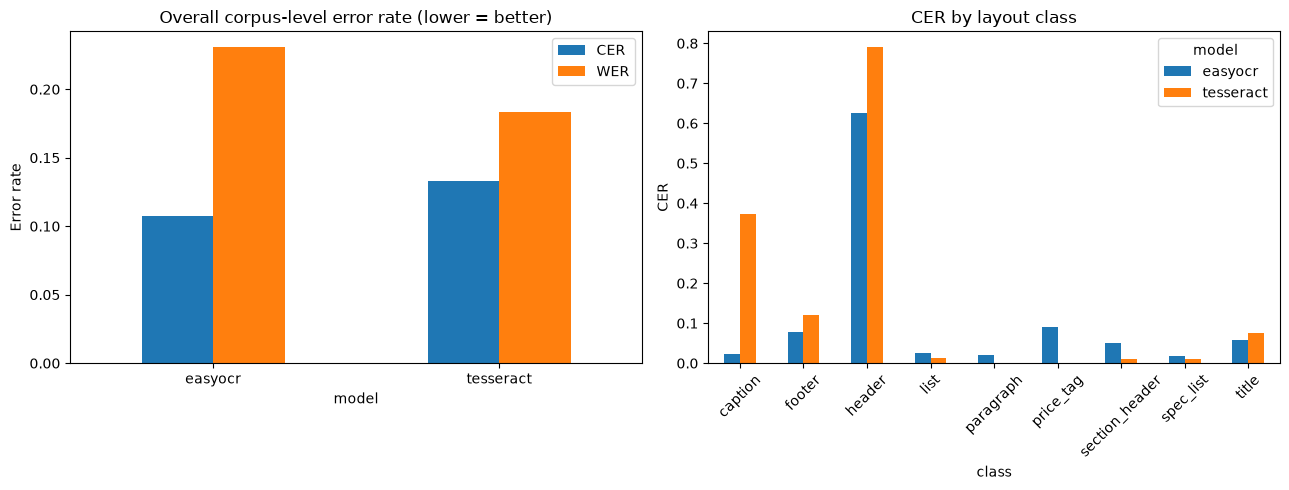

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

leaderboard[["corpus_CER", "corpus_WER"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set_title("Overall corpus-level error rate (lower = better)")
axes[0].set_ylabel("Error rate")
axes[0].legend(["CER", "WER"])

cer_pivot = per_class.pivot(index="class", columns="model", values="CER")
cer_pivot.plot(kind="bar", ax=axes[1], rot=45)
axes[1].set_title("CER by layout class")
axes[1].set_ylabel("CER")

plt.tight_layout()
plt.show()


## 11. Qualitative Spot-Check — Worst Zones per Model

In [13]:
worst = (results_df.sort_values("CER", ascending=False)
         .groupby("model", group_keys=False)
         .head(5)[["model", "id", "class", "gt_text", "pred_text", "CER", "WER"]])
worst


,model,id,class,gt_text,pred_text,CER,WER
1,tesseract,e0001,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 1 of...,MedCore ISO 13485:2016 | CE Marked | FDA 510(k HOU GI\nINSTRUMENTS INTERNATI...,0.808824,0.947368
59,tesseract,e0039,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 3 of...,MedCore ISO 13485:2016 | CE Marked | FDA 510(k HOGG\nINSTRUMENTS INTERNATION...,0.794118,0.894737
11,tesseract,e0007,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 2 of...,MedCore ISO 13485:2016 | CE Marked | FDA 510(k Page SN\nINSTRUMENTS INTERNAT...,0.779412,1.052632
87,tesseract,e0058,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 4 of...,MedCore ISO 13485:2016 | CE Marked | FDA 510(k Page ae\nINSTRUMENTS INTERNAT...,0.779412,1.052632
5,tesseract,e0004,title,2024 - 2025 PRODUCT CATALOGUE,0 UES £ULZOI PRAUYVUUT CALTALUUUE UL,0.758621,1.200000
58,easyocr,e0039,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 3 of...,MedCore Page 3 of 4\nINSTRUMENTS INTERNATIONAL ISO 13485.2016 1 CE Marked 3 ...,0.632353,0.789474
0,easyocr,e0001,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 1 of...,MedCore Page 1 of 4\nINSTRUMENTS INTERNATIONAL ISO 13485.2016 1 CE Marked 3 ...,0.632353,0.789474
10,easyocr,e0007,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 2 of...,MedCore Page 2 of 4\nINSTRUMENTS INTERNATIONAL ISO 13485.2016 1 CE Marked FD...,0.617647,0.789474
86,easyocr,e0058,header,MedCore\nINSTRUMENTS INTERNATIONAL\nPrecision. Reliability. Care.\nPage 4 of...,MedCore Page 4 of 4\nINSTRUMENTS INTERNATIONAL ISO 13485.2016 1 CE Marked FD...,0.617647,0.789474
4,easyocr,e0004,title,2024 - 2025 PRODUCT CATALOGUE,2uz4 Zuzj Phudu6i GATALOGUE,0.448276,1.000000


## 12. Save Outputs

In [14]:
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_path     = os.path.join(OUTPUT_DIR, "text_ocr_benchmark_per_zone_results.csv")
leaderboard_path = os.path.join(OUTPUT_DIR, "text_ocr_benchmark_leaderboard.csv")
per_class_path   = os.path.join(OUTPUT_DIR, "text_ocr_benchmark_per_class.csv")

results_df.to_csv(results_path, index=False)
leaderboard.to_csv(leaderboard_path)
per_class.to_csv(per_class_path, index=False)

print("Saved:")
for p in [results_path, leaderboard_path, per_class_path]:
    print(" -", p)


Saved:
 - /kaggle/working\text_ocr_benchmark_per_zone_results.csv
 - /kaggle/working\text_ocr_benchmark_leaderboard.csv
 - /kaggle/working\text_ocr_benchmark_per_class.csv


## Summary

This notebook benchmarks **EasyOCR** and **Tesseract** on the MedCore catalogue's
64 text-bearing layout zones, using the programmatically-verified `gt_text`
ground truth produced in the Text-GT-generation step.

**Metrics reported (per the Track A benchmarking plan):**
- **CER / WER** — corpus-level (micro-averaged, standard for OCR benchmarking) and macro-averaged (simple per-zone mean, useful to spot whether a few long zones dominate the corpus score)
- **Exact-match rate** — a blunt but intuitive sanity metric
- **Per-class breakdown** — to see whether errors concentrate in dense zones (`spec_list`, `list`) vs. short ones (`price_tag`, `title`)

**Next steps:** repeat this pattern for Track B (Table) and Track C (Image) once their respective GT files are generated, and feed all three into the unified leaderboard described in the benchmarking research report.
